In [2]:
from typing import List, TypedDict, Literal
from pydantic import BaseModel, Field

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langchain_community.tools.tavily_search import TavilySearchResults


from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
docs = (
    PyPDFLoader("./documents/Company_Policies.pdf").load()
    + PyPDFLoader("./documents/Company_Profile.pdf").load()
    + PyPDFLoader("./documents/Product_and_Pricing.pdf").load()
)

incorrect startxref pointer(1)
parsing for Object Streams
incorrect startxref pointer(1)
parsing for Object Streams
incorrect startxref pointer(1)
parsing for Object Streams


In [4]:
chunks = RecursiveCharacterTextSplitter(
    chunk_size=600, chunk_overlap=150
).split_documents(docs)

In [5]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = FAISS.from_documents(chunks, embeddings)
retriever = vector_store.as_retriever(search_kwargs={"k": 4})

In [6]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [7]:
class State(TypedDict):
    question: str
    need_retrieval: bool

    docs: List[Document]
    relevant_docs: List[Document]

    context: str
    answer: str

    # web query (no loop flags)
    web_query: str

In [8]:
class RetrieveDecision(BaseModel):
    should_retrieve: bool = Field(
        ...,
        description="True if external documents are needed to answer reliably, else False."
    )

decide_retrieval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You decide whether retrieval is needed.\n"
            "Return JSON that matches this schema:\n"
            "{{'should_retrieve': boolean}}\n\n"
            "Guidelines:\n"
            "- should_retrieve=True if answering requires specific facts, citations, or info likely not in the model.\n"
            "- should_retrieve=False for general explanations, definitions, or reasoning that doesn't need sources.\n"
            "- If unsure, choose True."
        ),
        ("human", "Question: {question}"),
    ]
)


# IMPORTANT: no `.content` for structured output
should_retrieve_llm = llm.with_structured_output(RetrieveDecision)

def decide_retrieval(state: "State"):
    decision: RetrieveDecision = should_retrieve_llm.invoke(
        decide_retrieval_prompt.format_messages(question=state["question"])
    )
    return {"need_retrieval": decision.should_retrieve}

In [9]:
direct_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Answer the question using only your general knowledge.\n"
            "Do NOT assume access to external documents.\n"
            "If you are unsure or the answer requires specific sources, say:\n"
            "'I don't know based on my general knowledge.'"
        ),
        ("human", "{question}"),
    ]
)


def generate_direct(state: State):
    out = llm.invoke(
        direct_generation_prompt.format_messages(
            question=state["question"]
        )
    )
    return {
        "answer": out.content
    }


In [10]:
def retrieve(state: State):
    return {"docs": retriever.invoke(state["question"])}

In [11]:
class RelevanceDecision(BaseModel):
    is_relevant: bool = Field(
        ...,
        description="True if the document helps answer the question, else False."
    )

is_relevant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are judging document relevance.\n"
            "Return JSON that matches this schema:\n"
            "{{'is_relevant': boolean}}\n\n"
            "A document is relevant if it contains information useful for answering the question."
        ),
        (
            "human",
            "Question:\n{question}\n\nDocument:\n{document}"
        ),
    ]
)

relevance_llm = llm.with_structured_output(RelevanceDecision)

def is_relevant(state: State):
    
    relevant_docs: List[Document] = []

    for doc in state["docs"]:
        decision: RelevanceDecision = relevance_llm.invoke(
            is_relevant_prompt.format_messages(
                question=state["question"],
                document=doc.page_content
            )
        )

        if decision.is_relevant:
            relevant_docs.append(doc)

    return {"relevant_docs": relevant_docs}



In [12]:
# New
rag_generation_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a business RAG assistant.\n"
            "Answer the user's question using ONLY the provided context.\n"
            "If the context does not contain enough information, say:\n"
            "'No relevant document found.'\n"
            "Do not use outside knowledge.\n"
        ),
        (
            "human",
            "Question:\n{question}\n\n"
            "Context:\n{context}\n"
        ),
    ]
)

def generate_from_context(state: State):
    # Stuff relevant docs into one block
    context = "\n\n---\n\n".join(
        [d.page_content for d in state.get("relevant_docs", [])]
    ).strip()

    if not context:
        return {"answer": "No relevant document found.", "context": ""}

    out = llm.invoke(
        rag_generation_prompt.format_messages(
            question=state["question"],
            context=context
        )
    )
    return {"answer": out.content, "context": context}


In [13]:
class WebQuery(BaseModel):
    query: str

rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query composed of keywords.\n"
            "Rules:\n"
            "- Keep it short (6–14 words).\n"
            "- If the question implies recency, add (last 30 days).\n"
            "- Do NOT answer the question.\n"
            "- Return JSON with a single key: query",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

def rewrite_query_node(state: State):
    out = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": out.query}

tavily = TavilySearchResults(max_results=5)

def web_search_node(state: State):
    q = state.get("web_query") or state["question"]
    results = tavily.invoke({"query": q})

    docs = []
    for r in results or []:
        title = r.get("title", "")
        url = r.get("url", "")
        content = r.get("content", "") or r.get("snippet", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        docs.append(
            Document(
                page_content=text,
                metadata={"source": "web", "url": url, "title": title},
            )
        )

    return {"docs": docs}


C:\Users\ritik\AppData\Local\Temp\ipykernel_28368\948566410.py:25: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults(max_results=5)


In [14]:
# New
def no_relevant_docs(state: State):
    return {"answer": "No relevant document found.", "context": ""}

In [15]:
def route_after_decide(state: State) -> Literal["generate_direct", "retrieve"]:
    if state["need_retrieval"]:
        return "retrieve"
    return "generate_direct"

In [16]:
def route_after_relevance(state: State) -> Literal["generate_from_context", "rewrite_query"]:
    if state.get("relevant_docs") and len(state["relevant_docs"]) > 0:
        return "generate_from_context"
    return "rewrite_query"


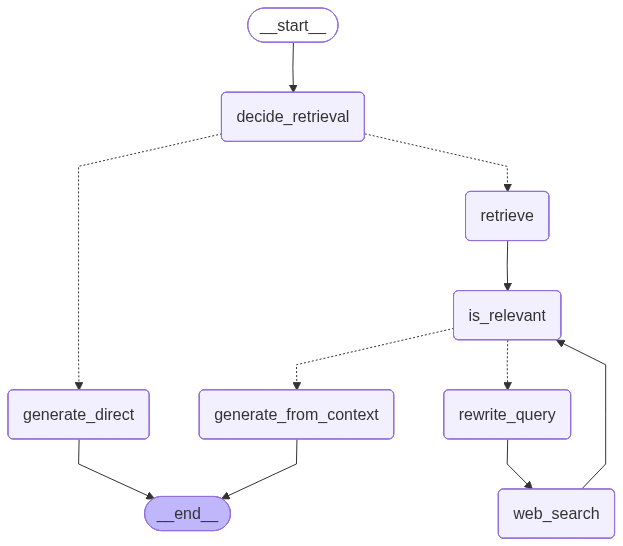

In [17]:
g = StateGraph(State)

g.add_node("decide_retrieval", decide_retrieval)
g.add_node("generate_direct", generate_direct)
g.add_node("retrieve", retrieve)

g.add_node("is_relevant", is_relevant)
g.add_node("generate_from_context", generate_from_context)

# ✅ new nodes (replace no_relevant_docs)
g.add_node("rewrite_query", rewrite_query_node)
g.add_node("web_search", web_search_node)

# --------------------
# Edges
# --------------------
g.add_edge(START, "decide_retrieval")

g.add_conditional_edges(
    "decide_retrieval",
    route_after_decide,
    {
        "generate_direct": "generate_direct",
        "retrieve": "retrieve",
    },
)

g.add_edge("generate_direct", END)

# vector retrieval → relevance
g.add_edge("retrieve", "is_relevant")

# relevance router: if relevant → generate, else → rewrite_query
g.add_conditional_edges(
    "is_relevant",
    route_after_relevance,
    {
        "generate_from_context": "generate_from_context",
        "rewrite_query": "rewrite_query",
    },
)

# web fallback path
g.add_edge("rewrite_query", "web_search")
g.add_edge("web_search", "is_relevant")  # 🔁 circle back

# final
g.add_edge("generate_from_context", END)

app = g.compile()
app


In [18]:
result = app.invoke(
    {
        "question": "Who won the Aus vs Zim World T20 match 2026 and who was the top scorer",
        "docs": [],
        "relevant_docs": [],
        "context": "",
        "answer": "",
    }
)

print(result["answer"])

Zimbabwe won the Aus vs Zim World T20 match in 2026 by 23 runs. The top scorer for Zimbabwe was Brian Bennett, who scored 64 not out. For Australia, Matt Renshaw was the top scorer with 65 runs.


In [19]:
for doc in result['relevant_docs']:
    print(doc.page_content)
    print("*"*100)

TITLE: AUS vs ZIM, T20 World Cup 2026: Australia stunned by Zimbabwe in Colombo
URL: https://www.olympics.com/en/news/t20-world-cup-2026-cricket-australia-vs-zimbabwe-group-b-match-report
CONTENT:
Despite Renshaw scoring a fighting 44-ball 65 - his maiden T20I half-centusy - wickets collapsed at the other end as the Aussies fell 23 runs short.

Blessing was the start of the show with career-best figures of 4/17, while Evans picked up 3/23.

This was Zimbabwe’s second T20I win over Australia in four meetings and the first since 2007. Incidentally, the first one came at the inaugural T20 World Cup.

Australia will face co-hosts Sri Lanka in their next T20 World Cup 2026 match in Kandy on Tuesday.

AUS vs ZIM, T20 World Cup 2026, brief scores: Zimbabwe 169/2 in 20 overs (Brian Bennett 64 not out; Cameron Green 1/6) beat Australia 146/10 in 19.3 overs (Matt Renshaw 65; Blessing Muzarabani 4/17) by 23 runs. [...] # AUS vs ZIM, T20 World Cup 2026: Australia stunned by Zimbabwe despite Matt R

In [20]:
len(result['relevant_docs'])

5